In [32]:
import itertools

from tqdm.notebook import tqdm
import pandas as pd
import math
import numpy as np

total_datapoints = 2033
max_judge_queries = total_datapoints*20
failure_probability_delta = 0.1

def judge_query(p_r_pair):
    """
    Queries a prompt response pair to the judge LLM
    :param p_a_pair:
    :return:
    """

def data_reader(filename):
    """
    Reads the data from the json file into a pandas dataset
    :return:
    """
    return pd.read_json(filename, lines=True)

class UCB:
    def __init__(self, n_pairs, df):
        self.n_pairs = n_pairs
        self.responses = [np.empty(0) for _ in range(n_pairs)]          # Number of times each arm was pulled
        self.dataframe = df

    def select_pair(self):
        # If any pair hasn't been tried 4log(1/\delta), try it first
        for pair in range(self.n_pairs):
            if self.responses[pair].shape[0] < math.log(1/failure_probability_delta,2)*4:
                return pair

        ucb_values = [0.0] * self.n_pairs

        for pair in range(self.n_pairs):

            ucb_values[pair] = self.get_ucb_value(pair)

        return ucb_values.index(max(ucb_values))

    def get_ucb_value(self, pair_number):
        return self.get_sample_covariance(self.responses[pair_number])/(1-(2*math.sqrt(math.log(1/failure_probability_delta,2)/self.responses[pair_number].shape[0])))

    def get_sample_covariance(self, selected_pair_responses):
        return np.square(selected_pair_responses-selected_pair_responses.mean()).sum()/(selected_pair_responses.shape[0]-1)

    def get_all_sample_covariance(self):
        to_return = []
        for pair in range(self.n_pairs):
            to_return.append(self.get_sample_covariance(self.responses[pair]))
        to_return = np.array(to_return)
        return to_return

    def update(self, chosen_pair):
        new_value = self.dataframe.iloc[chosen_pair*10+((self.responses[chosen_pair].shape[0])%10)]["predicted_score"]
        clipped_new_value = max(min(new_value, 5), 0)
        self.responses[chosen_pair] = np.append(self.responses[chosen_pair], clipped_new_value)

In [33]:
df = data_reader("helpsteer2.jsonl")
algorithm = UCB(total_datapoints, df)

In [34]:
for iteration in tqdm(range(int(max_judge_queries))):
    most_uncertain_pair = algorithm.select_pair()
    # if iteration < total_datapoints*2 and iteration % 10 == 0:
    #     print(most_uncertain_pair)
    if iteration > total_datapoints*14and iteration % 1000 == 0:
        print(most_uncertain_pair)
    algorithm.update(most_uncertain_pair)

<>:5: SyntaxWarning: invalid decimal literal
<>:5: SyntaxWarning: invalid decimal literal
C:\Users\anike\AppData\Local\Temp\ipykernel_12744\121720781.py:5: SyntaxWarning: invalid decimal literal
  if iteration > total_datapoints*14and iteration % 1000 == 0:


  0%|          | 0/40660 [00:00<?, ?it/s]

803
491
884
240
1542
809
114
1812
353
714
1502
639


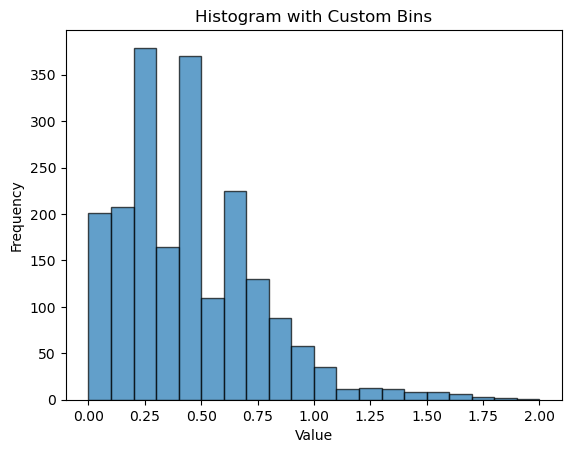

In [39]:
import matplotlib.pyplot as plt
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np

# Sample data
data = algorithm.get_all_sample_covariance()

# Specify custom bins
bins = [0, 0.1, 0.2, 0.3 ,0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3 ,1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2.0]

# Create histogram
plt.hist(data, bins=bins, edgecolor='black', alpha=0.7)
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('Histogram with Custom Bins')
plt.show()
